In [7]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import LineString
import utm
import os
import pandas as pd

In [8]:
# 经纬度坐标
lat  = 48.972494784142
lon = 8.478655532875

# 定义文件路径和中心点
center_point = (lat, lon)  # 替换为实际的经纬度值
dist = 40 # 裁剪距离，单位米
north, south, east, west = ox.utils_geo.bbox_from_point(center_point,dist=dist)

In [9]:
G = ox.graph.graph_from_point(center_point, dist=40, simplify=False, truncate_by_edge=True)

/home/users/xzh/anaconda3/envs/osmnx/lib/python3.8/site-packages/osmnx/graph.py:191: FutureWarning: The expected order of coordinates in `bbox` will change in the v2.0.0 release to `(left, bottom, right, top)`.
  G = graph_from_bbox(


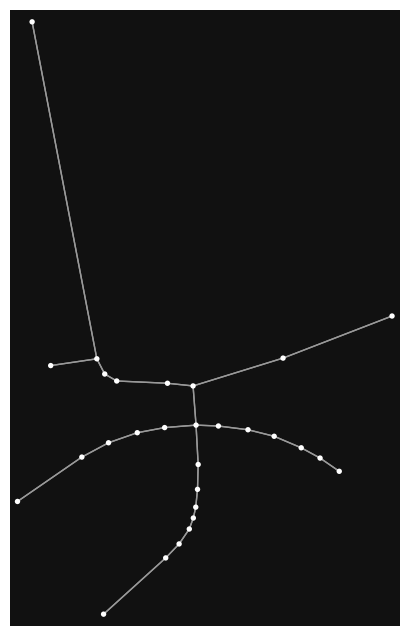

(<Figure size 800x800 with 1 Axes>, <AxesSubplot:>)

In [10]:
# 裁剪图以匹配边界框
graph_clipped = G
# 绘制图形
ox.plot_graph(graph_clipped)

In [11]:
# Directory containing the OXTS data files
directory = '/home/users/xzh/trajectory-prediction/datasets/my_test10/oxts/data/'
file_names = [f'{i:010}.txt' for i in range(6,76)]
# Construct full file paths
file_paths = [os.path.join(directory, name) for name in file_names]

# 读取 OXTS 数据文件，提取经纬度值
def read_oxts_files(file_paths):
    all_coords = []
    for file_path in file_paths:
        with open(file_path, 'r') as file:
            line = file.readline()
            data = list(map(float, line.split()))
            # 假设数据顺序为：lat, lon, alt, roll, pitch, yaw, pos_accuracy
            lat, lon = data[0], data[1]
            # print(f"lat: {lat}, lon: {lon}")
            all_coords.append((lon, lat))  # 注意这里经纬度的顺序
    return all_coords

all_coords_data = read_oxts_files(file_paths)
nodes = []
for coord in all_coords_data:
    # print(coord)
    node = ox.distance.nearest_nodes(graph_clipped, coord[0], coord[1])# 先lon,再lat
    # print(node)
    nodes.append(node)

route = nx.shortest_path(graph_clipped, nodes[0], nodes[-1], weight='length')
print(route)

[26939429, 1175051016, 7524547437, 26939430, 11285058569, 1175051060, 11285058570, 26939431]


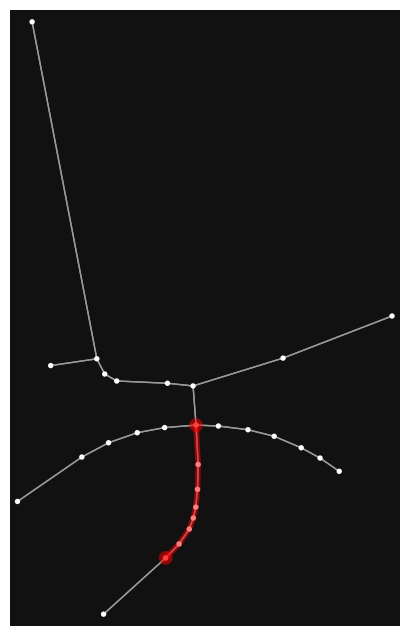

In [12]:
fig, ax = ox.plot_graph_route(graph_clipped, route) #可视化结果
# 显示图形
plt.show()

In [13]:
# 获取 nodes 和 edges 数据框
nodes, edges = ox.graph_to_gdfs(graph_clipped)
# 提取 route 中所有节点的经纬度信息
route_nodes = nodes.loc[route]
route_lat_lon = route_nodes[['y', 'x']]  # 'y' 是纬度，'x' 是经度

print(route_lat_lon)

                     y         x
osmid                           
26939429     48.972561  8.478661
1175051016   48.972454  8.478670
7524547437   48.972386  8.478668
26939430     48.972338  8.478660
11285058569  48.972308  8.478650
1175051060   48.972278  8.478634
11285058570  48.972237  8.478591
26939431     48.972199  8.478535


                         x             y
osmid                                   
26939429     461847.116039  5.424537e+06
1175051016   461847.678166  5.424525e+06
7524547437   461847.428837  5.424517e+06
26939430     461846.857595  5.424512e+06
11285058569  461846.095863  5.424508e+06
1175051060   461844.850819  5.424505e+06
11285058570  461841.724129  5.424501e+06
26939431     461837.618769  5.424496e+06


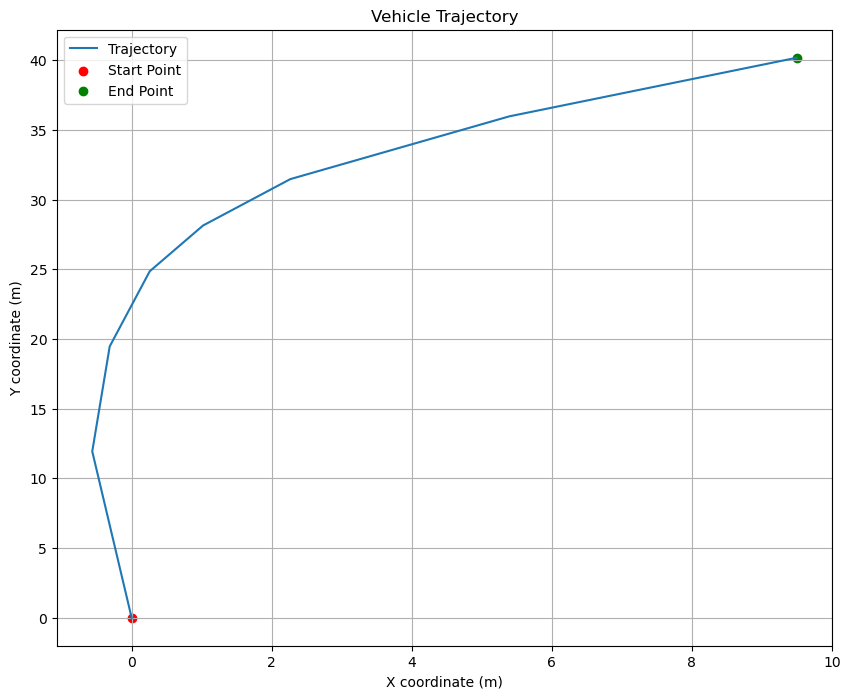

In [14]:
# 将unique_a转换为utm
def gps_to_utm(lat, lon):
    """
    Convert GPS coordinates (latitude, longitude, altitude) to UTM coordinates.

    Parameters:
    - lat: float, latitude in degrees
    - lon: float, longitude in degrees
    - alt: float, altitude in meters

    Returns:
    - x: float, UTM x-coordinate
    - y: float, UTM y-coordinate
    """
    x, y, zone_number, zone_letter = utm.from_latlon(lat, lon)
    return x, y
# 将 route_lat_lon 中的经纬度转换为 UTM 坐标
route_utm = route_lat_lon.apply(lambda row: gps_to_utm(row['y'], row['x']), axis=1)
route_utm = pd.DataFrame(route_utm.tolist(), columns=['x', 'y'], index=route_lat_lon.index)
print(route_utm)

# route_coords_utm = []
# for coord in unique_a:
#     print(coord)
#     x, y = gps_to_utm(coord[1], coord[0])
#     print(f"UTM coordinates: {x}, {y}")
#     route_coords_utm.append((x, y))

# Convert translations to a numpy array
translations = np.array(route_utm)

# Use the first point as the origin
translations -= translations[0]

# Plot the trajectory
plt.figure(figsize=(10, 8))
plt.plot(-translations[:, 0], -translations[:, 1], label='Trajectory')
plt.scatter(-translations[0, 0], -translations[0, 1], color='red', label='Start Point')
plt.scatter(-translations[-1, 0], -translations[-1, 1], color='green', label='End Point')
plt.title('Vehicle Trajectory')
plt.xlabel('X coordinate (m)')
plt.ylabel('Y coordinate (m)')
plt.legend()
plt.grid(True)
plt.show()